# Diagnostics related to variogram analysis

* skewness
* outliers

In [1]:
import os

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
import sys
sys.path.append('../src/')
from tqdm import tqdm
import warnings

from pyproj import CRS, Transformer
from geopy.distance import geodesic
from skgstat import Variogram, DirectionalVariogram

warnings.filterwarnings("ignore", message="Warning: converting a masked element to nan.")

import auxiliar_functions as aux

In [12]:
df = pd.DataFrame({'a': [1,2,3], 'b': [0,0,0]})

df2 = df[df["a"] > 1].copy()

df['a'] = [4,5,6]

df

,a,b
0,4,0
1,5,0
2,6,0


In [18]:
df2

,a,b
0,2,1
1,3,0


In [17]:
df2.reset_index(drop=True, inplace=True)
df2['b'][0] = 1

In [19]:
df

,a,b
0,4,0
1,5,0
2,6,0


In [ ]:
date = 0
aoi = [-15, 40, 30, 60] 


month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
dfs = {}
for monthid in [0, 1]:

    month = month_names[monthid]
    DATA_PATH = '/home/pietaril/Documents/data/CO2M_simulations/regridded_monthly_uncertainties/'
    uncertainties_1month = np.load(os.path.join(DATA_PATH, f'rg_uncert_{month}.npy'))
    if monthid == 6:
        # add missing cloud cover from xco2 to july data
        XCO2_PATH = '/home/pietaril/Documents/data/CO2M_simulations/regridded_monthly_xco2/'
        xco2_1month = np.load(os.path.join(XCO2_PATH, f'rg_xco2_{month}.npy'))
        uncertainties_1month[np.isnan(xco2_1month)] = np.nan

    uncertainties = uncertainties_1month
    period = '1month'       
    #create grid
    res = 0.1
    grid_xy = np.ogrid[aoi[0]:aoi[1]+res:res, aoi[2]:aoi[3]+res:res]
    grid_x, grid_y = grid_xy[0].reshape(1,-1)[0], grid_xy[1][0]
    coords = np.array([(i,j) for i in grid_x for j in grid_y])
    lon_rg, lat_rg = coords[:,0], coords[:,1]


    # save data to a pandas dataframe
    data = {'lon': lon_rg, 
        'lat': lat_rg, 
        'uncertainties': uncertainties}
    df = pd.DataFrame(data)

    # remove rows with NaN values
    df = df.dropna()

    df.reset_index(drop=True, inplace=True)
    df.sort_values(by=['lon', 'lat'], inplace=True)

    #convert lon, lat to x,y coordinates
    # NOTE: the projection can be changed to the one that fits the region of interest
    inProj = CRS("EPSG:4326") # WGS84
    outProj = CRS("EPSG:3035")
    transformer = Transformer.from_crs(inProj, outProj, always_xy=True)
    x, y = transformer.transform(df["lon"].values, df["lat"].values)
    # Add the xy coordinates to the dataframe
    df['x'] = x
    df['y'] = y

    dfs[month] = df



In [3]:
from scipy.stats import skew


In [4]:
month = "Feb"
data = dfs[month]

In [21]:
import statsmodels.api as sm
model = sm.OLS(data["uncertainties"], data["x"])
results = model.fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:          uncertainties   R-squared (uncentered):                   0.943
Model:                            OLS   Adj. R-squared (uncentered):              0.943
Method:                 Least Squares   F-statistic:                          8.499e+05
Date:                Tue, 01 Oct 2024   Prob (F-statistic):                        0.00
Time:                        14:33:30   Log-Likelihood:                          6549.4
No. Observations:               51333   AIC:                                 -1.310e+04
Df Residuals:                   51332   BIC:                                 -1.309e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x           2.023e-07   2.19e-10    921.917      0.000    2.02e-07    2.03e-07
==============================================================================
Omnibus:                       71.261   Durbin-Watson:                   0.198
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               70.351
Skew:                           0.081   Prob(JB):                     5.29e-16
Kurtosis:                       2.919   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 0.98, 'Feb xCO2 uncertainty spatial dependence')

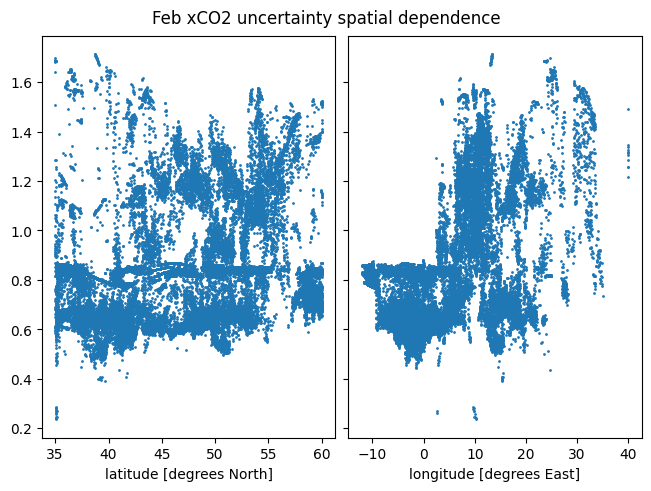

In [5]:
import matplotlib.pyplot as plt
month = "Feb"
data = dfs[month]

fig, axs = plt.subplots(1,2, layout="constrained", sharey=True)
axs[0].scatter(data["lat"], data["uncertainties"], s=1)
axs[0].set_xlabel("latitude [degrees North]")
axs[1].scatter(data["lon"], data["uncertainties"], s=1)
axs[1].set_xlabel("longitude [degrees East]")
fig.suptitle(f"{month} xCO2 uncertainty spatial dependence")



Text(0.5, 0.98, 'Feb xCO2 uncertainty spatial dependence')

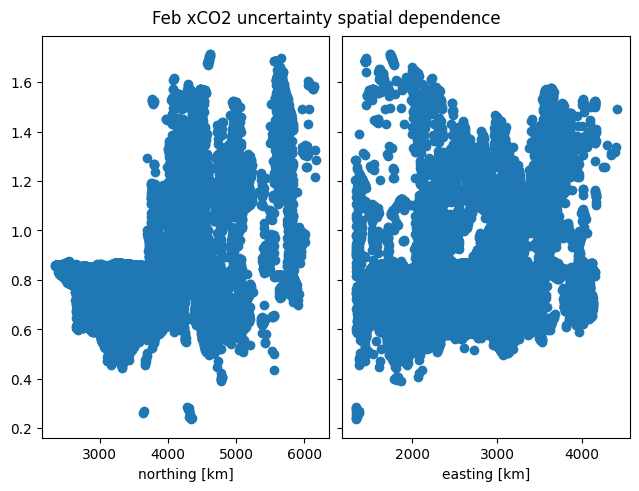

In [6]:
fig, axs = plt.subplots(1,2, layout="constrained", sharey=True)
axs[0].scatter(data["x"]/1000, data["uncertainties"])
axs[0].set_xlabel("northing [km]")
axs[1].scatter(data["y"]/1000, data["uncertainties"])
axs[1].set_xlabel("easting [km]")
fig.suptitle(f"{month} xCO2 uncertainty spatial dependence")


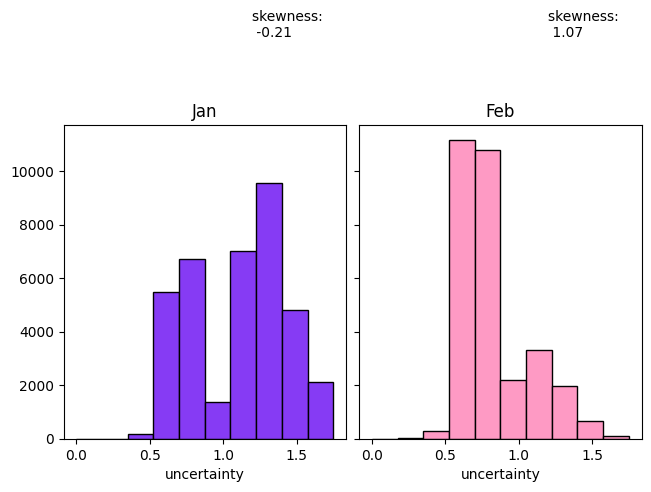

In [7]:
months = ["Jan", "Feb"]


fig, axs = plt.subplots(1, 2, layout="constrained", sharey=True)

for i in range(2):
    uncs = dfs[months[i]].uncertainties
    if i == 0:
        _, bins, _ = axs[i].hist(uncs, color=np.random.rand(3,), range = [0., 1.75], edgecolor="black")
    else:
        _ = axs[i].hist(uncs, bins=bins, color=np.random.rand(3,), edgecolor = "black")
    axs[i].set_title(months[i])
    axs[i].set_xlabel("uncertainty")

    axs[i].text(1.2, 15000, f"skewness: \n {skew(uncs):.2f}")

Text(0, 0.5, 'uncertainty [ppm]')

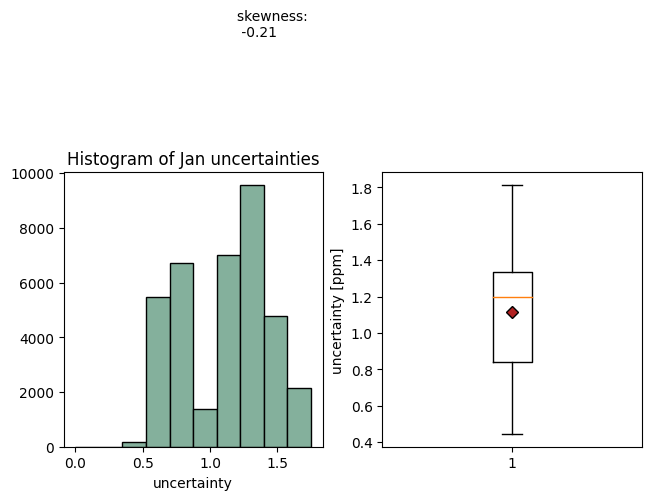

In [11]:
month = "Jan"

fig, axs = plt.subplots(1, 2, layout="constrained")
uncs = dfs[month].uncertainties

_, bins, _ = axs[0].hist(uncs, color=np.random.rand(3,), range = [0., 1.75], edgecolor="black")

axs[0].set_title(f"Histogram of {month} uncertainties")
axs[0].set_xlabel("uncertainty")

axs[0].text(1.2, 15000, f"skewness: \n {skew(uncs):.2f}")
meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor='firebrick')


axs[1].boxplot(uncs, meanprops=meanpointprops, meanline=False, showmeans=True) 
axs[1].set_ylabel("uncertainty [ppm]")

Text(0, 0.5, 'uncertainty [ppm]')

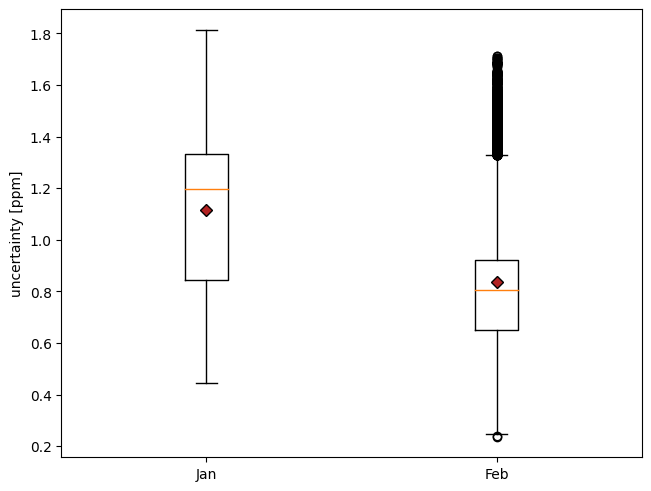

In [10]:
months = ["Jan", "Feb"]
uncs = [dfs["Jan"].uncertainties, dfs["Feb"].uncertainties]

fig, ax = plt.subplots(layout="constrained")

labels = months
colors = [np.random.rand(3,), np.random.rand(3,)]

meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor='firebrick')


plt.boxplot(uncs, meanprops=meanpointprops, meanline=False, showmeans=True) 
ax.set_xticklabels(months)
ax.set_ylabel("uncertainty [ppm]")


{'whiskers': [<matplotlib.lines.Line2D at 0x7fec33b23070>,
 'caps': [<matplotlib.lines.Line2D at 0x7fec33b23160>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fec33b23760>],
 'medians': [<matplotlib.lines.Line2D at 0x7fec33b23a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fec33b22a70>],
 'means': []}

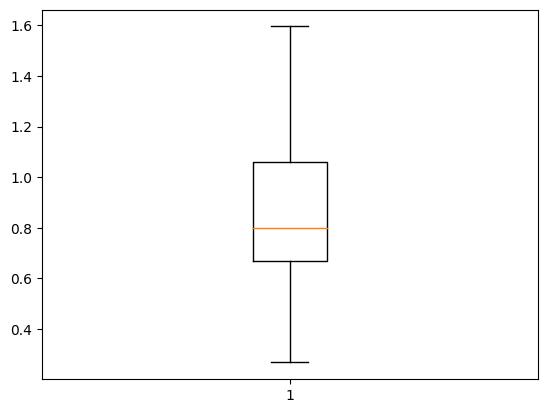

In [41]:
plt.boxplot(dfs["Aug"].uncertainties)